# The registered test, first review on spot

The trend lane registered one test before running it, so its result carries no search penalty. This is its first review, on Data A, Binance spot from August 2017 to December 2019, data the lane had never loaded.

The registered book, fixed before this run.

- Per coin sign of the trailing return, averaged over 3, 4, 5 and 6 weeks.
- Weighted by inverse 12-week volatility, gross one, rebalanced at the Sunday close.
- Coins with a trailing 30-day median dollar volume of at least \$10M, as of the week before.
- Costed off the measured ladder at a \$100k book, with the 10 bps spot taker fee.
- One trial. Any other cut of this data is exploratory.

The registered rules. Pass needs a probability real of 0.95 over Data A and the forward perps run pooled, plus every other check. Park sits between 0.5 and 0.95 with the two agreeing. Fail is a probability below 0.5, or a negative Sharpe on Data A alone. This review can settle the fail rules. Pass and park wait on the forward run.

## Loading spot

Every USDT spot pair the archive carried from August 2017 to December 2019, delisted included. The bars come through the qp source where the engine module is built, and straight from the archive otherwise. Both read the same files. Stablecoins, fiat, tokenised gold and leveraged tokens are dropped, since they are not coins that trend. The same cleaning as the perps panel follows. A day counts only if something traded, no return spans a halt, and a coin's first 30 trading days are skipped. Spot pays no funding. Spot cannot be shorted without a borrow, so the short side is a paper return.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qp_research import costs, data, gate, panel, plot
from qp_research.book import Book, inverse_vol
from qp_research.data import universe
from qp_research.plot import BLUE, GREY
import signals, spot
from signals import sharpe

warnings.filterwarnings('ignore')
plot.style()

START, END = '2017-08-01', '2020-01-01'
bars, source = data.daily_bars(universe.spot_pairs(), START, END, market='spot'), 'qp source'
p = panel.build(panel.bars(bars))
W, LIQ = p.returns, p.liquidity
# The perps cost ladder, half spread and depth against daily dollar volume on log scales.
FIT = costs.Ladder(spread=(2.00175, -0.27263), depth=(-0.71735, 0.81857))
SIZE = 1e5
tb = Book(p, costs.Taker(costs.FEES['spot'], FIT, SIZE))
sized = lambda sig: inverse_vol(p, sig)

def run(w, **kw):
    return tb.run(w, **kw)

tradeable = (LIQ >= 1e7) & W.notna()
print(f'bars from the {source}')
print(f'pairs {bars.symbol.nunique()}   weeks {len(W)}   {W.index[0].date()} .. {W.index[-1].date()}')
print('coins over $10M a day, mean per week by year', tradeable.sum(axis=1).groupby(tradeable.index.year).mean().round(1).to_dict())

bars from the qp source
pairs 86   weeks 125   2017-08-20 .. 2020-01-05
coins over $10M a day, mean per week by year {2017: 0.5, 2018: 7.5, 2019: 8.4, 2020: 0.0}


86 coin pairs traded in the window. Liquid coins were few. Over \$10M a day averaged under one coin a week in 2017, 7.5 in 2018 and 8.4 in 2019.

Two contract events sit in the window. VEN swapped into VET in July 2018 and left one stray print at 0.0001 in October, which the named redenomination list keeps out of PnL. BCC was renamed BCHABC at the November 2018 fork and runs as two coins, the second starting after its 30-day warm-up.

## Checking the loader

The archive reader is new, so check it against the tested pipeline. Where the engine module is built, read the same window both ways and compare every bar. A symbol-day in one and not the other, or a close or volume that differs, means one loader is wrong.

In [2]:
ref = spot.daily_bars(START, END)
j = bars.merge(ref, on=['symbol', 'day'], how='outer', suffixes=('', '_archive'), indicator=True)
both = j[j._merge == 'both']
print(f"bars only in the qp source {int((j._merge == 'left_only').sum())}   only in the archive reader {int((j._merge == 'right_only').sum())}")
print(f"largest close gap {(both.close / both.close_archive - 1).abs().max():.1e}   largest volume gap {(both.volume / both.volume_archive - 1).abs().max():.1e}")

BCCUSDT missing 2018-11-16, no daily file
BCCUSDT missing 2018-11-17, no daily file
BCCUSDT missing 2018-11-18, no daily file
BCCUSDT missing 2018-11-19, no daily file
VENUSDT missing 2018-07-24, no daily file
VENUSDT missing 2018-07-25, no daily file
VENUSDT missing 2018-07-26, no daily file
VENUSDT missing 2018-07-27, no daily file
VENUSDT missing 2018-07-28, no daily file
VENUSDT missing 2018-07-29, no daily file
VENUSDT missing 2018-07-30, no daily file
VENUSDT missing 2018-07-31, no daily file
VENUSDT missing 2018-08-01, no daily file
VENUSDT missing 2018-08-02, no daily file
VENUSDT missing 2018-08-03, no daily file
VENUSDT missing 2018-08-04, no daily file
VENUSDT missing 2018-08-05, no daily file
VENUSDT missing 2018-08-06, no daily file
VENUSDT missing 2018-08-07, no daily file
VENUSDT missing 2018-08-08, no daily file
VENUSDT missing 2018-08-09, no daily file
VENUSDT missing 2018-08-10, no daily file
VENUSDT missing 2018-08-11, no daily file
VENUSDT missing 2018-08-12, no dai

The two loaders agree exactly. No symbol-day is in one and not the other, every close matches, and the largest volume difference is $2.2 \times 10^{-16}$, rounding. The bars above came through the qp source, so the result stands on the tested pipeline. The missing days the archive reader logs are the VEN swap and the BCC rename.

## Checking the backtest before believing it

Three checks, the same as on the perps. Random signs should lose roughly the cost of trading. A signal one week older should do worse, or the backtest is seeing the future. And zero, one and two times cost should give three different answers.

In [3]:
def band(lookbacks=(3, 4, 5, 6)):
    return sum(np.sign(W.rolling(L, min_periods=L).sum()) for L in lookbacks) / len(lookbacks)

rng = np.random.default_rng(0)
rand = [sharpe(run(sized(pd.DataFrame(rng.choice([-1.0, 1.0], size=W.shape), index=W.index, columns=W.columns)
                           .where(W.shift(1).notna()))).net) for _ in range(20)]
print(f'random signs, 20 runs   net Sharpe mean {np.mean(rand):+.2f}   range {min(rand):+.2f} .. {max(rand):+.2f}')
for lag in [1, 2]:
    print(f'registered book, signal {lag} week old   net Sharpe {sharpe(run(sized(band().shift(lag))).net):+.2f}')
w = sized(band().shift(1))
print('registered book at 0x 1x 2x cost', [round(sharpe(run(w, cost_mult=m).net), 2) for m in (0.0, 1.0, 2.0)])

random signs, 20 runs   net Sharpe mean -0.17   range -1.33 .. +0.98
registered book, signal 1 week old   net Sharpe +1.03
registered book, signal 2 week old   net Sharpe +0.96
registered book at 0x 1x 2x cost [1.08, 1.03, 0.98]


All three pass, the second only just. Random signs average $-0.17$ and reach $+0.98$ at best. With six to eight coins a week a random book swings widely, and the registered book at 1.03 sits barely above the best random run. A week-old signal falls only to 0.96, a weak separation. The three cost levels give three answers, 1.08, 1.03 and 0.98.

## The registered book

The signal averages four trend signs, one per lookback.

$$s_{i,t} = \frac{1}{4} \sum_{L=3}^{6} \operatorname{sign}\Big( \sum_{k=0}^{L-1} r_{i,t-k} \Big)$$

- $r_{i,t-k}$ is coin $i$'s log return in week $t-k$.
- The inner sum is its trailing $L$-week return, and its sign votes long or short.
- The outer sum averages the four votes, so the signal runs from $-1$ to $+1$ in quarters. Lookbacks that disagree shrink the position.

The position is $s_{i,t}$ over the coin's volatility, scaled so absolute weights sum to one, and it trades the week after. Read the net Sharpe, where the money goes, and the years.

net Sharpe 1.03   gross 1.08   return +93.8% a year   cost -4.9% a year   turnover 0.59 a week   weeks 112
coins held per week {'min': 0.0, '50%': 6.0, 'max': 12.0}
net Sharpe by year {2017: '+7.15 (7w)', 2018: '+0.30 (52w)', 2019: '+0.46 (52w)', 2020: '+nan (1w)'}
2017 weeks, the coins held {'2017-11-19': 'BTC', '2017-11-26': 'BTC', '2017-12-03': 'BTC', '2017-12-10': 'BTC', '2017-12-17': 'BTC ETH', '2017-12-24': 'BTC ETH', '2017-12-31': 'BTC ETH'}
share of net from 2017 72%   from 2018 Sharpe 0.37 over 105 weeks


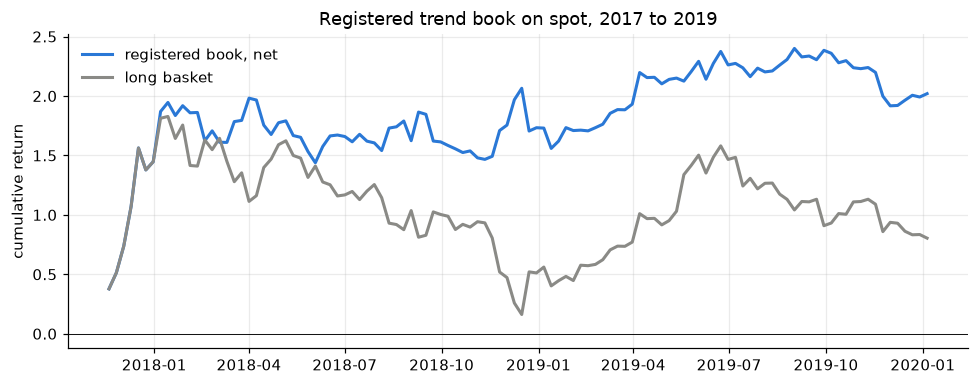

In [4]:
r = run(w)
print(f'net Sharpe {sharpe(r.net):.2f}   gross {sharpe(r.gross):.2f}   return {r.net.mean() * 5200:+.1f}% a year   '
      f'cost {r.cost.mean() * 5200:.1f}% a year   turnover {r.turnover.mean():.2f} a week   weeks {len(r)}')
print('coins held per week', (w.abs() > 0).sum(axis=1).loc[r.index].describe()[['min', '50%', 'max']].to_dict())
print('net Sharpe by year', {y: f'{sharpe(g):+.2f} ({len(g)}w)' for y, g in r.net.groupby(r.net.index.year)})

y2018 = pd.Timestamp('2018-01-01', tz='UTC')
print('2017 weeks, the coins held', {str(t.date()): ' '.join(k[:-4] for k, v in w.loc[t].items() if abs(v) > 0) for t in r.index[r.index < y2018]})
print(f'share of net from 2017 {r.net[r.index < y2018].sum() / r.net.sum():.0%}   from 2018 Sharpe {sharpe(r.net[r.index >= y2018]):.2f} over {int((r.index >= y2018).sum())} weeks')
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(r.index, r.net.cumsum(), color=BLUE, label='registered book, net')
ax.plot(r.index, run(signals.basket(p)).net.reindex(r.index).cumsum(), color=GREY, label='long basket')
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('cumulative return')
ax.set_title('Registered trend book on spot, 2017 to 2019'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The book makes 1.03 net over 112 weeks, 94% a year, paying 4.9% a year in cost at 0.59 turnover a week. It holds 6 coins in a typical week and never more than 12.

The return is not spread across the years. The 7 weeks of 2017 make 7.15, and 2018 and 2019 make 0.30 and 0.46. In those 7 weeks the book held only BTC, then BTC and ETH, long through the top of the December 2017 bubble, and they carry 72% of the whole net return. From 2018, with six to eight coins, the book makes 0.37 over 105 weeks.

## Against the gate

One trial, so the luck bar is zero and the significance check is the plain probability the Sharpe is above nothing, corrected for skew and fat tails. The checks Data A can settle run here. Out of sample agreement waits on the forward run, and so does coverage, since 2017 to 2019 alone is under five years. The cost ladder stays open, fit on 2023 to 2026 perps depth.

In [5]:
x = r.net
prob, bar = gate.significance(x, 1.0)
s2, keep = gate.year_stability(x)
base = {'long basket': sharpe(run(signals.basket(p)).net), 'short basket': sharpe(run(-signals.basket(p)).net),
        'persistence': sharpe(run(sized(np.sign(W).shift(1))).net)}
late = sharpe(run(sized(band().shift(2))).net)
twice = sharpe(run(w, cost_mult=2.0).net)
boot = gate.bootstrap(x)
checks = {'S1': ('pass' if prob >= gate.CONFIDENCE else 'park' if prob >= gate.PARK else 'fail', f'probability {prob:.2f}, Sharpe {sharpe(x):.2f}, {len(x)} weeks'),
          'S2': ('pass' if s2 else 'fail', f'worst year removed keeps {keep:.0%} of the Sharpe'),
          'S6': ('pass' if sharpe(x) > max(base.values()) else 'fail', ', '.join(f'{k} {v:.2f}' for k, v in base.items())),
          'T1': ('pass' if late <= sharpe(x) else 'fail', f'one week older {late:.2f}'),
          'C4': ('pass' if twice > 0 else 'fail', f'twice cost {twice:.2f}'),
          'V1': ('pass' if boot['sharpe 5%'] > 0 else 'fail', f"5th percentile {boot['sharpe 5%']:.2f}, ends above zero {boot['ends above zero']:.0%}, median drawdown {boot['drawdown 50%']:.2f}")}
for k, (status, note) in checks.items():
    print(f'{k}  {status:5} {note}')
failed = [k for k, (st, _) in checks.items() if st == 'fail' and k != 'S1']
print()
print('stamp on Data A', gate.stamp(failed, prob, sharpe(x), 1.0, 52, open_items=['D1', 'S3', 'T5']))
print('registered fail rules on Data A', {'negative Sharpe': bool(sharpe(x) < 0), 'probability below 0.5': bool(prob < gate.PARK)})

S1  park  probability 0.94, Sharpe 1.03, 112 weeks
S2  fail  worst year removed keeps 36% of the Sharpe
S6  pass  long basket 0.36, short basket -0.39, persistence -0.35
T1  pass  one week older 0.96
C4  pass  twice cost 0.98
V1  fail  5th percentile -0.50, ends above zero 82%, median drawdown -0.80

stamp on Data A gate fail S2 V1, open D1 S3 T5
registered fail rules on Data A {'negative Sharpe': False, 'probability below 0.5': False}


One trial, so the probability real is the plain chance the Sharpe is above zero. It is 0.94, just short of 0.95.

- S2 fails. Removing 2017 keeps 36% of the Sharpe.
- V1 fails. The bootstrap 5th percentile is $-0.50$, 82% of paths end above zero, and the median worst drawdown is 0.80.
- S6 passes. The long basket makes 0.36, the short basket $-0.39$ and persistence $-0.35$.
- T1 passes weakly at 0.96, and C4 passes at 0.98.

The stamp on Data A is `gate fail S2 V1, open D1 S3 T5`. The registered fail rules are not met. The Sharpe is positive and the probability 0.94 sits above 0.5, so the registered test continues to the forward run.

## Verdict

Data A does not refute the registered test, and it adds little support. The book makes 1.03 with a probability of 0.94 on one trial, and neither registered fail rule fires, so the test continues to the forward perps run.

But 72% of that return is 7 weeks of holding BTC and ETH long through the December 2017 bubble, a market bet on one or two coins. From 2018, with six to eight coins, it makes 0.37, and a random-sign book on the same coins reaches 0.98. On Data A alone the gate's year and bootstrap checks fail. Spot from 2017 to 2019 was too thin in coins and too short in time to say much.